## Homework 2

> [!NOTE]
> This homework uses the pinned 2026 car fuel-efficiency release in the course
> repository. The plan and report are available in `cohorts/2026/data/`.

### Dataset

For this homework, we'll use the 2026 Car Fuel Efficiency dataset. Download it from <a href='https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'>here</a>.

You can do it with wget:
```bash
wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
```

The goal of this homework is to create a regression model for predicting the car fuel efficiency (column `'fuel_efficiency_mpg'`).

### Preparing the dataset 

Use only the following columns:

* `'engine_displacement'`,
* `'horsepower'`,
* `'vehicle_weight'`,
* `'model_year'`,
* `'fuel_efficiency_mpg'`

### EDA

* Look at the `fuel_efficiency_mpg` variable. Does it have a long tail? 

### Question 1

There's one column with missing values. What is it?

* `'engine_displacement'`
* `'horsepower'`
* `'vehicle_weight'`
* `'model_year'`


### Question 2

What's the median (50% percentile) for variable `'horsepower'`?

- 204
- 254
- 304
- 354

### Prepare and split the dataset

Shuffle the filtered dataset and create the split exactly as in the lecture:

```python
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]
```

For Q5, repeat the same block with each listed seed. For Q6, use seed `9`.


### Question 3

* We need to deal with missing values for the column from Q1.
* We have two options: fill it with 0 or with the mean of this variable.
* Try both options. For each, train a linear regression model without regularization using the code from the lessons.
* For computing the mean, use the training only!
* Use the validation dataset to evaluate the models and compare the RMSE of each option.
* Round the RMSE scores to 3 decimal digits using `round(score, 3)`. This
  keeps the imputation difference visible in this release.
* Which option gives better RMSE?

Options:

- With 0
- With mean
- Both are equally good


### Question 4

* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0. 
* Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 4 decimal digits. This keeps the small but real
  regularization differences visible instead of turning several choices into a tie.
* Which `r` gives the best RMSE?

If multiple options give the same best RMSE, select the smallest `r`.

Options:

- 0
- 0.01
- 0.1
- 1
- 5
- 10
- 100


### Question 5 

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores. 
* What's the standard deviation of all the scores? To compute the standard deviation, use `np.std`.
* Round the result to 3 decimal digits (`round(std, 3)`)

What's the value of std?

- 0.006
- 0.016
- 0.029
- 0.036

> Note: Standard deviation shows how different the values are.
> If it's low, then all values are approximately the same.
> If it's high, the values are different. 
> If standard deviation of scores is low, then our model is *stable*.


### Question 6

* Split the dataset like previously, use seed 9.
* Combine train and validation datasets.
* Fill the missing values with 0 and train a model with `r=0.001`. 
* What's the RMSE on the test dataset?

Options:

- 0.236
- 2.236
- 22.10
- 221.0

## Submit the results

* Submit your results here: https://courses.datatalks.club/ml-zoomcamp-2026/homework/hw02
* The numerical options are calculated from the pinned 2026 release. Use the value that matches your calculation; do not choose a merely close value.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')

In [3]:
df.head(5)

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [4]:
# Size of DataFrame
len(df)

10000

In [5]:
df.info

<bound method DataFrame.info of       model_year  origin fuel_type         drivetrain  num_doors  \
0           2006  Europe  Gasoline  Front-wheel drive          4   
1           2008  Europe    Diesel  Front-wheel drive          4   
2           1996    Asia  Gasoline  Front-wheel drive          5   
3           1989  Europe  Gasoline  Front-wheel drive          4   
4           1994     USA    Diesel  Front-wheel drive          3   
...          ...     ...       ...                ...        ...   
9995        2005     USA  Gasoline    All-wheel drive          4   
9996        1993    Asia  Gasoline    All-wheel drive          2   
9997        2014     USA  Gasoline    All-wheel drive          3   
9998        2004     USA    Hybrid   Rear-wheel drive          5   
9999        2011     USA    Diesel  Front-wheel drive          4   

      engine_displacement  num_cylinders  horsepower  vehicle_weight  \
0                    2180              6       243.0            3870   
1      

## EDA

In [6]:
# Look at the fuel_efficiency_mpg variable. Does it have a long tail?
# Visualizing the fuel_efficiency_mpg column by looking at its distribution
import matplotlib.pyplot as plt
import seaborn as sns

# assure that plots are displayed in jupyter notebook's cells
%matplotlib inline

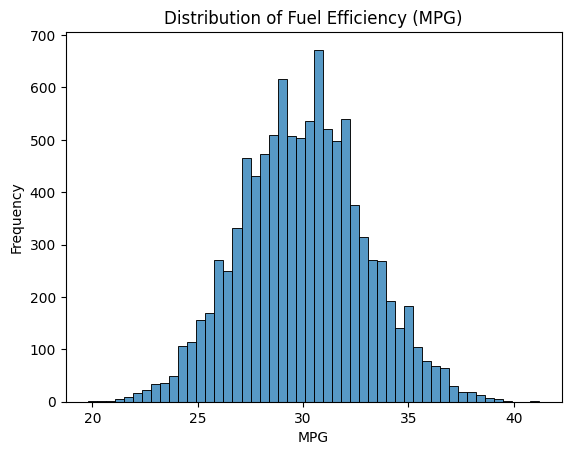

In [7]:
sns.histplot(df.fuel_efficiency_mpg, bins=50) #show the histogram of a series
plt.title('Distribution of Fuel Efficiency (MPG)')
plt.xlabel('MPG')
plt.ylabel('Frequency')
plt.show()

# NO, It's a normal distribution

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

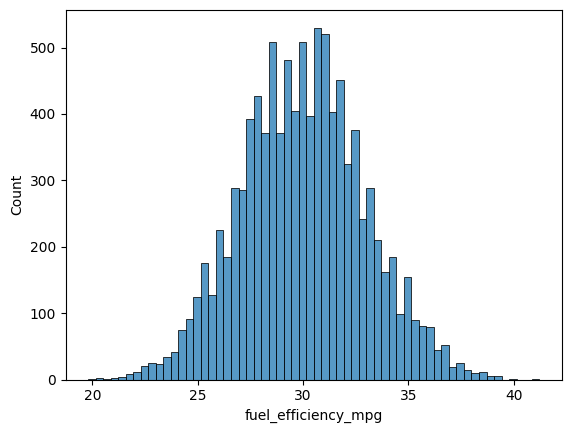

In [13]:
sns.histplot(df['fuel_efficiency_mpg'])

In [16]:
df.dtypes

model_year               int64
origin                  object
fuel_type               object
drivetrain              object
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [8]:
# Q1. There's one column with missing values. What is it?

selected_columns = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]

# Count missing values in each selected column
missing_counts = df[selected_columns].isnull().sum()
print(missing_counts)

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64


In [9]:
# Mean
mean_hp = df['horsepower'].mean()
print("Mean horsepower:", mean_hp)

Mean horsepower: 254.44601556505535


In [10]:
# Median
median_value = df['horsepower'].median()
print("Median horsepower:", median_value)

Median horsepower: 254.0


In [11]:
# Mode
mode_value = df['horsepower'].mode()
print("Median horsepower:", mode_value)

Median horsepower: 0    252.0
Name: horsepower, dtype: float64


In [12]:
# Question 2. Median for horse power 

median_hp = df['horsepower'].median()
print("Median horsepower:", median_hp)

Median horsepower: 254.0


In [14]:
# Prepare and split the dataset
# Shuffle the filtered dataset and create the split exactly as in the lecture:

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

### Question 3

* We need to deal with missing values for the column from Q1.
* We have two options: fill it with 0 or with the mean of this variable.
* Try both options. For each, train a linear regression model without regularization using the code from the lessons.
* For computing the mean, use the training only!
* Use the validation dataset to evaluate the models and compare the RMSE of each option.
* Round the RMSE scores to 3 decimal digits using `round(score, 3)`. This
  keeps the imputation difference visible in this release.
* Which option gives better RMSE?

Options:

- With 0
- With mean
- Both are equally good

In [15]:
import numpy as np

# Get the length of dataset
n = len(df)

# Calculate split sizes
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

# Create index array and shuffle
idx = np.arange(n)
np.random.seed(42)  # Setting seed as required
np.random.shuffle(idx)

# Split the data
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

# Reset indices
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# Get target variable
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [17]:
def rmse(y, y_pred):
    error = (y - y_pred) ** 2
    mse = error.mean()

    return np.sqrt(mse)


def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]


def prepare_X(df):
    X = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']].values
    return X

In [18]:
# Approach 1: Fill with 0
df_train_zero = df_train.copy()
df_val_zero = df_val.copy()
df_train_zero['horsepower'] = df_train_zero['horsepower'].fillna(0)
df_val_zero['horsepower'] = df_val_zero['horsepower'].fillna(0)

In [19]:
# Approach 2: Fill with mean from training
mean_horsepower = df_train['horsepower'].mean()
df_train_mean = df_train.copy()
df_val_mean = df_val.copy()
df_train_mean['horsepower'] = df_train_mean['horsepower'].fillna(mean_horsepower)
df_val_mean['horsepower'] = df_val_mean['horsepower'].fillna(mean_horsepower)

In [20]:
# Train and evaluate model with zeros
X_train_zero = prepare_X(df_train_zero)
w0_zero, w_zero = train_linear_regression(X_train_zero, y_train)

X_val_zero = prepare_X(df_val_zero)
y_pred_zero = w0_zero + X_val_zero.dot(w_zero)
rmse_zero = round(np.sqrt(rmse(y_val, y_pred_zero)), 2)

In [21]:
# Train and evaluate model with mean
X_train_mean = prepare_X(df_train_mean)
w0_mean, w_mean = train_linear_regression(X_train_mean, y_train)

X_val_mean = prepare_X(df_val_mean)
y_pred_mean = w0_mean + X_val_mean.dot(w_mean)
rmse_mean = round(np.sqrt(rmse(y_val, y_pred_mean)), 2)

In [22]:
print(f'RMSE with zeros: {rmse_zero}')
print(f'RMSE with mean: {rmse_mean}')

RMSE with zeros: 1.49
RMSE with mean: 1.48


### Question 4

* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0. 
* Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 4 decimal digits. This keeps the small but real
  regularization differences visible instead of turning several choices into a tie.
* Which `r` gives the best RMSE?

If multiple options give the same best RMSE, select the smallest `r`.

Options:

- 0
- 0.01
- 0.1
- 1
- 5
- 10
- 100

In [23]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [24]:
# Prepare data with zeros for missing values
df_train_zero = df_train.copy()
df_val_zero = df_val.copy()
df_train_zero['horsepower'] = df_train_zero['horsepower'].fillna(0)
df_val_zero['horsepower'] = df_val_zero['horsepower'].fillna(0)

In [25]:
# Prepare features
X_train = prepare_X(df_train_zero)
X_val = prepare_X(df_val_zero)

In [26]:
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
rmse_scores = {}

for r in r_values:
    # Train model
    w0, w = train_linear_regression_reg(X_train, y_train, r)
    
    # Make predictions
    y_pred = w0 + X_val.dot(w)
    
    # Calculate RMSE
    rmse_score = np.sqrt(rmse(y_val, y_pred))
    rmse_scores[r] = rmse_score
    print(f'r={r}, RMSE={rmse_score}')

r=0, RMSE=1.485022961018225
r=0.01, RMSE=1.4852028873770349
r=0.1, RMSE=1.4913561874302141
r=1, RMSE=1.5327194421654142
r=5, RMSE=1.5522178218921616
r=10, RMSE=1.5554645175873527
r=100, RMSE=1.5585897914513078


In [27]:
best_r = min([r for r in r_values if rmse_scores[r] == min(rmse_scores.values())])
print(f'\nBest r value: {best_r} (RMSE={rmse_scores[best_r]})')


Best r value: 0 (RMSE=1.485022961018225)


### Question 5 

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores. 
* What's the standard deviation of all the scores? To compute the standard deviation, use `np.std`.
* Round the result to 3 decimal digits (`round(std, 3)`)

What's the value of std?

- 0.006
- 0.016
- 0.029
- 0.036

> Note: Standard deviation shows how different the values are.
> If it's low, then all values are approximately the same.
> If it's high, the values are different. 
> If standard deviation of scores is low, then our model is *stable*.

In [28]:
def calculate_rmse_for_seed(seed, df):
    # Split the data
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test
    
    # Create index array and shuffle
    idx = np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(idx)
    
    # Split into train/val/test
    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train+n_val]].reset_index(drop=True)
    
    # Fill missing values with 0
    df_train_zero = df_train.copy()
    df_val_zero = df_val.copy()
    df_train_zero['horsepower'] = df_train_zero['horsepower'].fillna(0)
    df_val_zero['horsepower'] = df_val_zero['horsepower'].fillna(0)
    
    # Prepare features and target
    X_train = prepare_X(df_train_zero)
    X_val = prepare_X(df_val_zero)
    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    
    # Train model and make predictions
    w0, w = train_linear_regression(X_train, y_train)
    y_pred = w0 + X_val.dot(w)
    
    # Calculate RMSE
    return np.sqrt(rmse(y_val, y_pred))

In [29]:
# Calculate RMSE for each seed
seeds = list(range(10))  # [0,1,2,3,4,5,6,7,8,9]
rmse_scores = []

for seed in seeds:
    rmse_score = calculate_rmse_for_seed(seed, df)
    rmse_scores.append(rmse_score)
    print(f'Seed {seed}, RMSE: {rmse_score:.3f}')

Seed 0, RMSE: 1.496
Seed 1, RMSE: 1.484
Seed 2, RMSE: 1.471
Seed 3, RMSE: 1.485
Seed 4, RMSE: 1.484
Seed 5, RMSE: 1.499
Seed 6, RMSE: 1.507
Seed 7, RMSE: 1.480
Seed 8, RMSE: 1.489
Seed 9, RMSE: 1.486


In [30]:
# Calculate standard deviation
std = round(np.std(rmse_scores), 3)
print(f'\nStandard deviation of RMSE scores: {std}')


Standard deviation of RMSE scores: 0.01


### Question 6

* Split the dataset like previously, use seed 9.
* Combine train and validation datasets.
* Fill the missing values with 0 and train a model with `r=0.001`. 
* What's the RMSE on the test dataset?

Options:

- 0.236
- 2.236
- 22.10
- 221.0

## Submit the results

* Submit your results here: https://courses.datatalks.club/ml-zoomcamp-2026/homework/hw02
* The numerical options are calculated from the pinned 2026 release. Use the value that matches your calculation; do not choose a merely close value.

In [31]:
val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

# Create index array and shuffle with seed 9
idx = np.arange(n)
np.random.seed(9)
np.random.shuffle(idx)

# Split the data
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

# Combine train and validation sets
df_train_val = pd.concat([df_train, df_val])
df_train_val = df_train_val.reset_index(drop=True)

# Fill missing values with 0
df_train_val['horsepower'] = df_train_val['horsepower'].fillna(0)
df_test['horsepower'] = df_test['horsepower'].fillna(0)

# Prepare features
X_train_val = prepare_X(df_train_val)
X_test = prepare_X(df_test)

# Prepare target
y_train_val = df_train_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

# Train model with r=0.001
w0, w = train_linear_regression_reg(X_train_val, y_train_val, r=0.001)

# Make predictions
y_pred = w0 + X_test.dot(w)

# Calculate final RMSE
final_rmse = rmse(y_test, y_pred)
print(f'Final RMSE on test: {final_rmse:.3f}')

Final RMSE on test: 2.236


C:\Users\pc\AppData\Local\Temp\ipykernel_32608\3289062291.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['horsepower'] = df_test['horsepower'].fillna(0)


In [34]:
len(df) 

10000

In [35]:
len(df) * 0.2

2000.0

In [36]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = int(n * 0.6)

In [38]:
n, n_val + n_test + n_train

(10000, 10000)

In [39]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [40]:
n, n_val + n_test + n_train

(10000, 10000)

In [41]:
n_val, n_test, n_train

(2000, 2000, 6000)

In [44]:
df.iloc[[0,1,2]]

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
